<a href="https://colab.research.google.com/github/ImNotDanish05/2026_Cloud-Computing_TI-2A/blob/main/Jobsheet_5/Jupiter_Program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2. Install Library dan File**

In [1]:
!pip install -U pandas scikit-learn matplotlib wordcloud openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 39.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed.

In [2]:
import requests

url = 'https://raw.githubusercontent.com/ImNotDanish05/2026_Cloud-Computing_TI-2A/main/Jobsheet_5/data_prep_v2.xlsx'
filename = 'data_prep_v2.xlsx'

response = requests.get(url)
with open(filename, 'wb') as f:
    f.write(response.content)

print(f'Downloaded {filename}')

Downloaded data_prep_v2.xlsx


**3. Import Library**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast
import re
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud

**4. Load Data + Cleaning Data**

In [4]:
# Ganti path bila perlu; pastikan file ada di folder kerja Jupyter
df = pd.read_excel("data_prep_v2.xlsx")

# Pastikan kolom wajib ada
assert {'stemming', 'sentimen'}.issubset(df.columns), "Kolom 'stemming' dan/atau 'sentimen' tidak ditemukan."

# Pembersihan ringan
df = df.copy()
df['stemming'] = df['stemming'].astype(str).str.strip()
df['sentimen'] = df['sentimen'].astype(str).str.strip().str.lower()  # seragamkan label

# Drop duplikat & NA pada kolom inti
df = df.drop_duplicates(subset=['stemming', 'sentimen']).dropna(subset=['stemming', 'sentimen']).reset_index(drop=True)

df.head()

,Unnamed: 0,stemming,sentimen
0,0,"['bagus', 'nder', 'bentuk', 'laptop']",positif
1,1,"['sesuai', 'butuh', 'memang', 'lihat', 'harga'...",positif
2,2,"['sudah', 'bagus', 'banget', 'si', 'processor'...",positif
3,3,"['please', 'gue', 'muak', 'banget', 'lot']",negatif
4,4,"['huaaah', 'laptop', 'idaman', 'banget', 'nih'...",positif


**5. Fungsi Penghitung Kata Terbanyak per Kelas**

In [5]:
def explode_tokens(series):
    for text in series:
        tokens = []
        if isinstance(text, list):
            tokens = [str(t).strip().lower() for t in text if str(t).strip()]
        else:
            s = str(text).strip()
            if s.startswith("[") and s.endswith("]"):
                try:
                    lst = ast.literal_eval(s)
                    if isinstance(lst, list):
                        tokens = [str(t).strip().lower() for t in lst if str(t).strip()]
                    else:
                        tokens = re.findall(r"\b\w+\b", s.lower())
                except Exception:
                    tokens = re.findall(r"\b\w+\b", s.lower())
            else:
                tokens = re.findall(r"\b\w+\b", s.lower())
        yield tokens

def top_words_per_class(df, text_col="stemming", topn=5):
    cnt = Counter()
    for tokens in explode_tokens(df[text_col]):
        cnt.update(tokens)
    return pd.DataFrame(cnt.most_common(topn), columns=["word", "count"])

**6. Frekuensi Top 5 Per-Kelas Sentimen**

In [6]:
negatif = df[df["sentimen"] == "negatif"]
netral  = df[df["sentimen"] == "netral"]
positif = df[df["sentimen"] == "positif"]

dneg = top_words_per_class(negatif)
dnet = top_words_per_class(netral)
dpos = top_words_per_class(positif)

print("Negatif:\n", dneg)
print("\nNetral:\n", dnet)
print("\nPositif:\n", dpos)

Negatif:
        word  count
0    banget     15
1     kalau     13
2    laptop     13
3  keyboard     12
4      yang      8

Netral:
      word  count
0   pakai     21
1   sudah     14
2  laptop     13
3    juta     11
4    saja     11

Positif:
      word  count
0   bagus     22
1  laptop     22
2   harga     19
3   sudah     19
4   pakai     19


**7. Siapkan Data untuk Model Naive Bayes**

In [7]:
X_text = df["stemming"].astype(str).values
y_text = df["sentimen"].astype(str).values

le = LabelEncoder()
y = le.fit_transform(y_text)

print("Mapping Label:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping Label: {'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


**8. Split Data (Train/Test)**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    pd.Series(X_text).to_numpy(),
    pd.Series(y).to_numpy(),
    test_size=0.15,
    random_state=42,
    stratify=y
)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b\w+\b",
        ngram_range=(1, 1)
    )),
    ("clf", MultinomialNB())
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w+\\b'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None


**9. Evaluasi Train & Test**

In [9]:
y_pred = pipe.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy:.2f}")

Classification Report:
              precision    recall  f1-score   support

     negatif       0.50      0.25      0.33         8
      netral       0.00      0.00      0.00         9
     positif       0.54      1.00      0.70        15

    accuracy                           0.53        32
   macro avg       0.35      0.42      0.34        32
weighted avg       0.38      0.53      0.41        32


Confusion Matrix:
[[ 2  0  6]
 [ 2  0  7]
 [ 0  0 15]]

Overall Accuracy: 0.53


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**10. Cross-Validation**

In [10]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
# Convert inputs to standard numpy arrays to avoid indexing errors
scores = cross_val_score(pipe, np.array(X_text), np.array(y), cv=cv, scoring='accuracy')

print("Akurasi per Fold:", np.round(scores, 3))
print("Rata-rata Akurasi:", np.mean(scores))
print("Standar Deviasi:", np.std(scores))

Akurasi per Fold: [0.409 0.545 0.571 0.571 0.571 0.714 0.476 0.524 0.429 0.476]
Rata-rata Akurasi: 0.5287878787878788
Standar Deviasi: 0.08370804605633465


### Sentiment Visualizations
Below we generate Word Clouds for each sentiment class and a comparison of the top keywords.

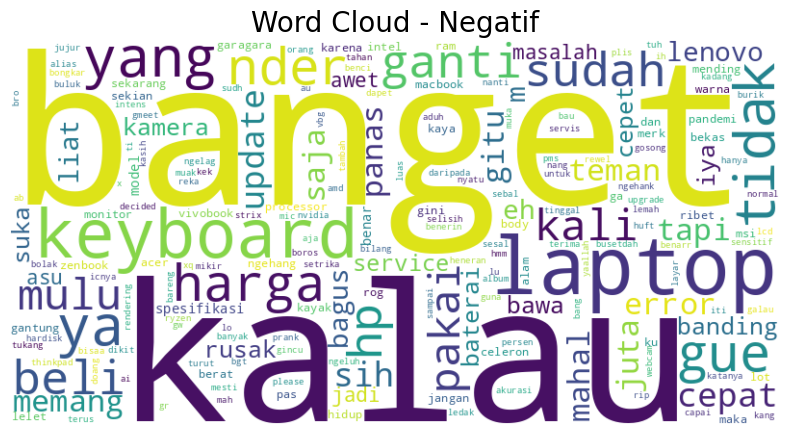

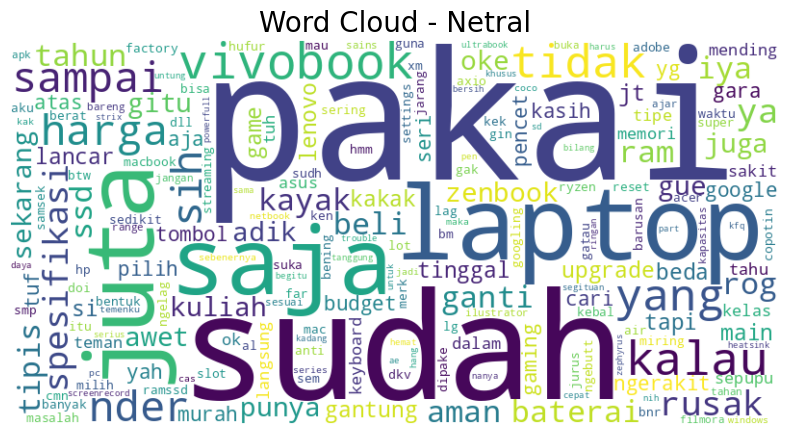

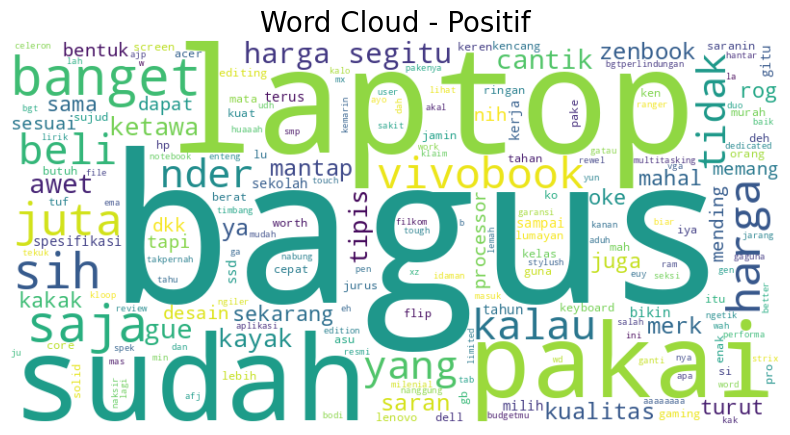

In [11]:
def show_wordcloud(data, title):
    text = " ".join([" ".join(tokens) for tokens in explode_tokens(data)])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

# Display Word Clouds
show_wordcloud(negatif['stemming'], 'Word Cloud - Negatif')
show_wordcloud(netral['stemming'], 'Word Cloud - Netral')
show_wordcloud(positif['stemming'], 'Word Cloud - Positif')

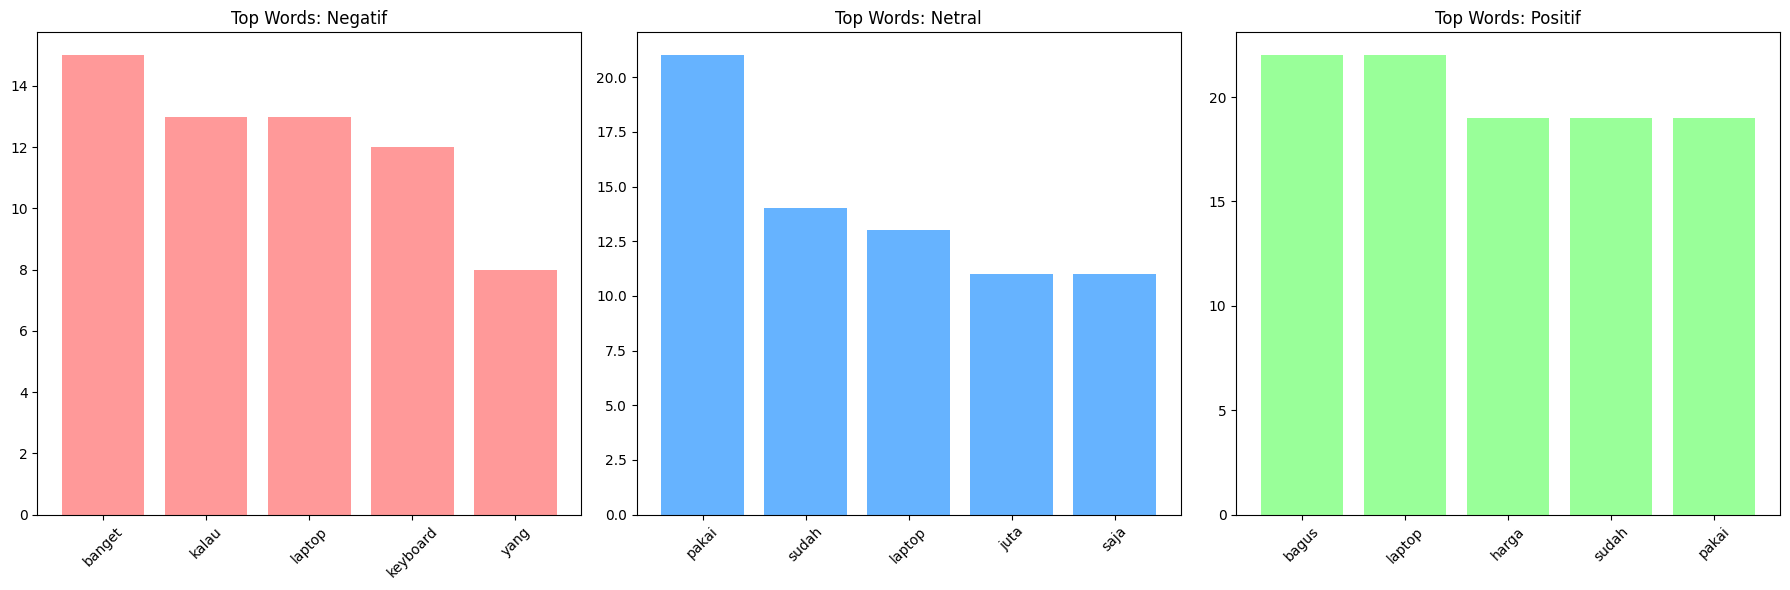

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns_colors = ['#ff9999','#66b3ff','#99ff99']
for i, (data, label) in enumerate(zip([dneg, dnet, dpos], ['Negatif', 'Netral', 'Positif'])):
    axes[i].bar(data['word'], data['count'], color=sns_colors[i])
    axes[i].set_title(f'Top Words: {label}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

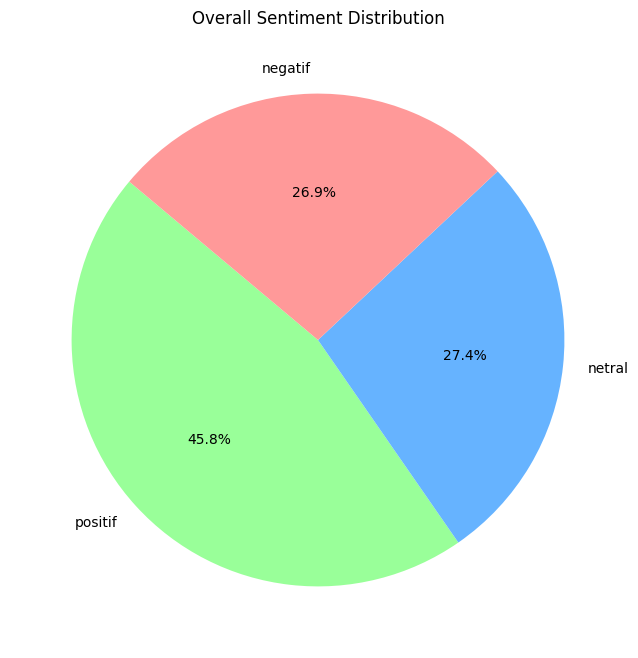

In [13]:
sentiment_counts = df['sentimen'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#99ff99', '#66b3ff', '#ff9999'], startangle=140)
plt.title('Overall Sentiment Distribution')
plt.show()

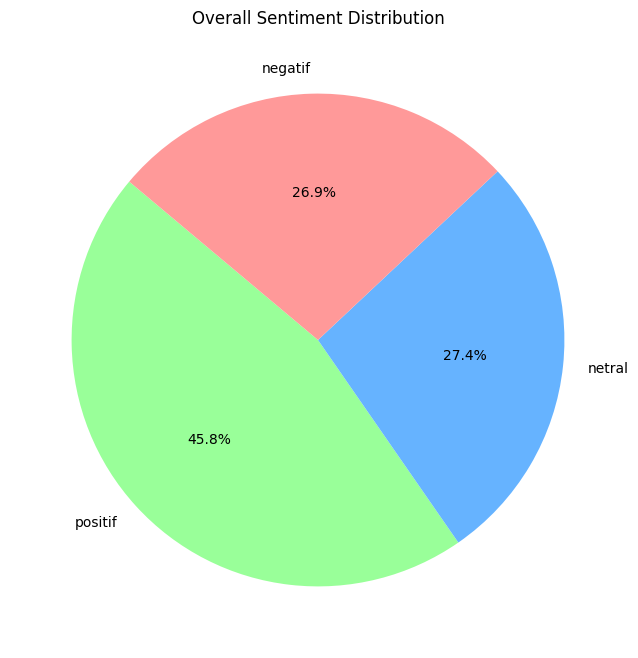

In [14]:
sentiment_counts = df['sentimen'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#99ff99', '#66b3ff', '#ff9999'], startangle=140)
plt.title('Overall Sentiment Distribution')
plt.show()

/tmp/ipykernel_3923/1478649093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#99ff99', '#66b3ff', '#ff9999'])


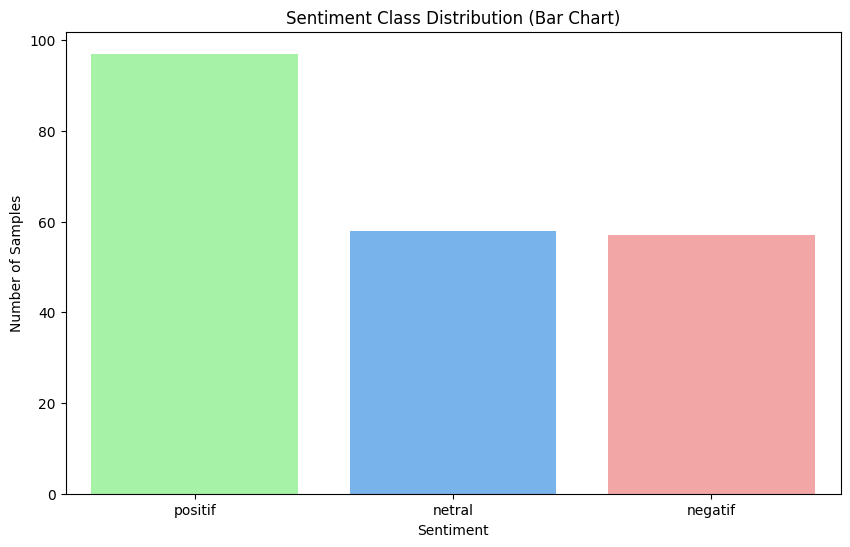

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#99ff99', '#66b3ff', '#ff9999'])
plt.title('Sentiment Class Distribution (Bar Chart)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Samples')
plt.show()

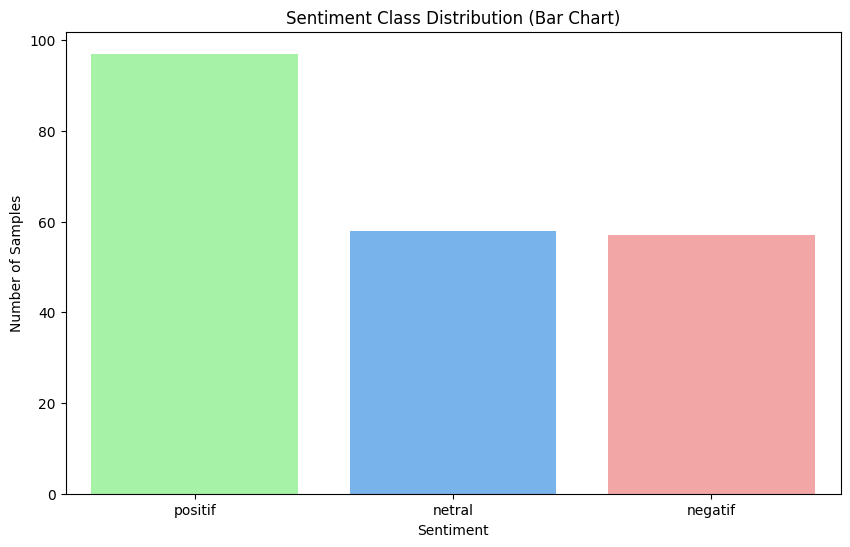

In [16]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    hue=sentiment_counts.index,
    palette=['#99ff99', '#66b3ff', '#ff9999'],
    legend=False
)
plt.title('Sentiment Class Distribution (Bar Chart)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Samples')
plt.show()